# 05_main_analysis.ipynb — 統合分析（完成版）

前処理・クラスタリング・遷移分析・プロビット分析を一本化した完成版ノートブック。

**04_review で確認した修正事項を全て反映：**
- `signed_log1p` を全変数に統一（赤字・累積損失企業の選択バイアス除去）
- 短期・長期借入金の欠損を 0 補完（無借金企業を分析に含める）
- cluster 0 を全分析に含める（route_map のバグ修正）
- 多項ロジットに出発クラスターダミーを追加
- 年度固定効果をプロビット・多項ロジットに追加

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'IPAexGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set(style='whitegrid', font='IPAexGothic')

# 再現性のためのシード
SEED = 42
N_CLUSTERS = 5

---
## 1. 前処理（修正版）

### 修正点
| 修正前 | 修正後 | 理由 |
|---|---|---|
| `log1p` 適用（負値→NaN） | `signed_log1p` 統一 | 赤字企業・累積損失企業の除外を防ぐ |
| 短期・長期借入金の欠損を削除 | **0 補完**してから変換 | 無借金企業を分析に含める |

In [2]:
# 元データ読み込み
raw = pd.read_csv('../data/raw/financial_data_clean.csv')

# 分析使用変数を選択
selected_cols = [
    'コード', '年度', '銘柄名',
    '総資産', '売上高', '自己資本比率',
    '短期借入金', '長期借入金',
    '利益剰余金', '現金同等物', '営業利益',
    '営業CF', '投資CF', '財務CF'
]
df = raw[selected_cols].copy()

print('元データ: ', df.shape)

元データ:  (54278, 14)


In [3]:
# --- 修正①: 借入ゼロ補完 ---
# 短期・長期借入金のNaNは「借入なし=0」として扱う
df['短期借入金'] = df['短期借入金'].fillna(0)
df['長期借入金'] = df['長期借入金'].fillna(0)

# --- 異常値除外（自己資本比率が極端に低い観測） ---
df = df[df['自己資本比率'] >= -200]

# --- 修正②: signed_log1p を全変数に統一 ---
# signed_log1p(x) = sign(x) * log1p(|x|)  ← 正値では log1p と同一, 負値にも対応
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

transform_cols = [
    '総資産', '売上高', '短期借入金', '長期借入金',
    '利益剰余金', '現金同等物', '営業利益',
    '営業CF', '投資CF', '財務CF'
]

for col in transform_cols:
    df[col + '_log'] = signed_log1p(df[col])

# 分析に使う列のみ残す
feature_cols = [c + '_log' for c in transform_cols] + ['自己資本比率']
key_cols     = ['コード', '年度', '銘柄名']

df_clean = df[key_cols + feature_cols].dropna(subset=feature_cols).reset_index(drop=True)

print('前処理後サンプル数:', len(df_clean))
print('ユニーク企業数:', df_clean['コード'].nunique())
print('年度範囲:', df_clean['年度'].min(), '〜', df_clean['年度'].max())
print()
print('欠損なし確認:')
print(df_clean[feature_cols].isnull().sum())

前処理後サンプル数: 49642
ユニーク企業数: 3558
年度範囲: 2010 〜 2025

欠損なし確認:
総資産_log      0
売上高_log      0
短期借入金_log    0
長期借入金_log    0
利益剰余金_log    0
現金同等物_log    0
営業利益_log     0
営業CF_log     0
投資CF_log     0
財務CF_log     0
自己資本比率       0
dtype: int64


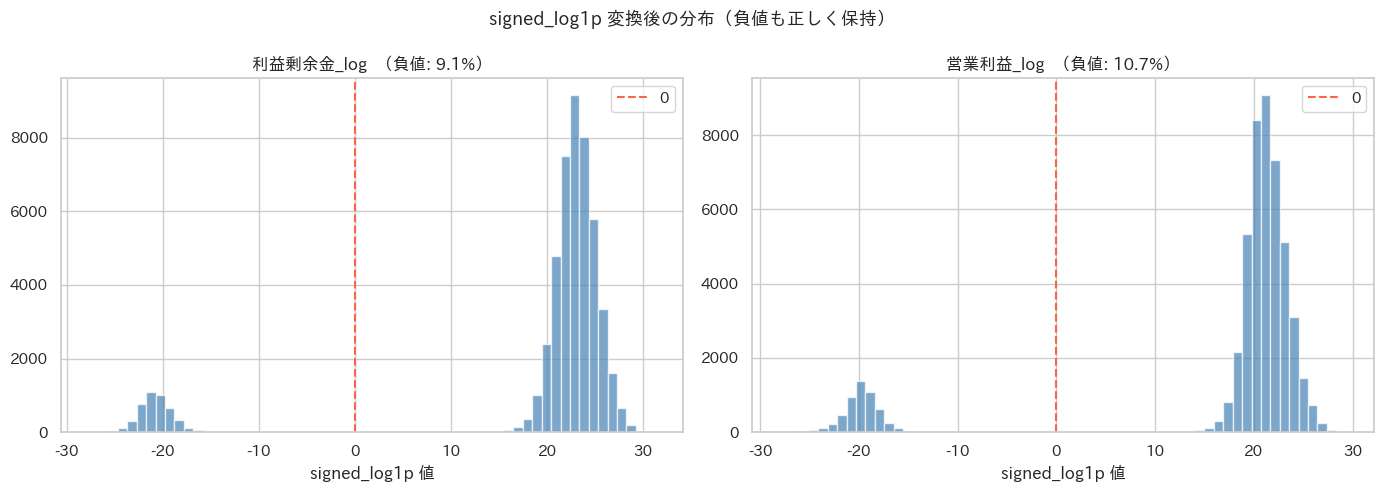

In [4]:
# 変換後の分布確認（利益剰余金・営業利益：負値が正しく含まれているか）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['利益剰余金_log', '営業利益_log']):
    ax.hist(df_clean[col], bins=60, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='tomato', linestyle='--', label='0')
    neg_pct = (df_clean[col] < 0).mean() * 100
    ax.set_title(f'{col}  （負値: {neg_pct:.1f}%）')
    ax.set_xlabel('signed_log1p 値')
    ax.legend()

plt.suptitle('signed_log1p 変換後の分布（負値も正しく保持）', fontsize=13)
plt.tight_layout()
plt.show()

### 結果と示唆

- 旧前処理（log1p）では 営業利益 **10.9%**、利益剰余金 **9.3%** が NaN → 削除されていた
- 修正後（signed_log1p）では **負値を保持したまま分析**に含めることができる
- 短期・長期借入金の 0 補完により、**無借金経営企業も分析対象**に含まれる
- これにより財務的に脆弱な企業・健全な企業の両端が正確に表現される

In [5]:
# クリーンデータを保存
Path('../data/interim').mkdir(parents=True, exist_ok=True)
df_clean.to_csv('../data/interim/cleaned_data_v2.csv', index=False)
print('保存: ../data/interim/cleaned_data_v2.csv')

保存: ../data/interim/cleaned_data_v2.csv


---
## 2. 年度内標準化

各変数を年度ごとに z スコア標準化する。  
これにより **「その年の他社と比べた相対的地位」** を捉え、時系列トレンドを除去する。  
> 注：絶対的な財務規模の成長ではなく、ピア比較上の立ち位置の変化を分析する設計

In [6]:
def z_score(x):
    return (x - x.mean()) / x.std()

df_std = df_clean.copy()
df_std[feature_cols] = df_clean.groupby('年度')[feature_cols].transform(z_score)

# 確認: 各年度の平均が 0 に収束しているか
check = df_std.groupby('年度')[feature_cols].mean().abs().max(axis=1)
print('年度別平均の最大絶対値（0 に近いほど正常）:')
print(check.describe().round(6))

年度別平均の最大絶対値（0 に近いほど正常）:
count    16.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64


---
## 3. 主成分分析（PCA）

In [7]:
X_std = df_std[feature_cols].values

pca = PCA(random_state=SEED)
pca.fit(X_std)

evr     = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

print('寄与率・累積寄与率:')
for i, (e, c) in enumerate(zip(evr, cum_evr)):
    used = '  ← 使用' if i < 3 else ''
    print(f'  PC{i+1:2d}: {e*100:5.1f}%  (累積 {c*100:5.1f}%){used}')

寄与率・累積寄与率:
  PC 1:  35.0%  (累積  35.0%)  ← 使用
  PC 2:  19.5%  (累積  54.5%)  ← 使用
  PC 3:  10.0%  (累積  64.5%)  ← 使用
  PC 4:   9.1%  (累積  73.6%)
  PC 5:   6.9%  (累積  80.5%)
  PC 6:   5.5%  (累積  86.0%)
  PC 7:   4.7%  (累積  90.7%)
  PC 8:   4.1%  (累積  94.8%)
  PC 9:   3.7%  (累積  98.4%)
  PC10:   1.1%  (累積  99.5%)
  PC11:   0.5%  (累積 100.0%)


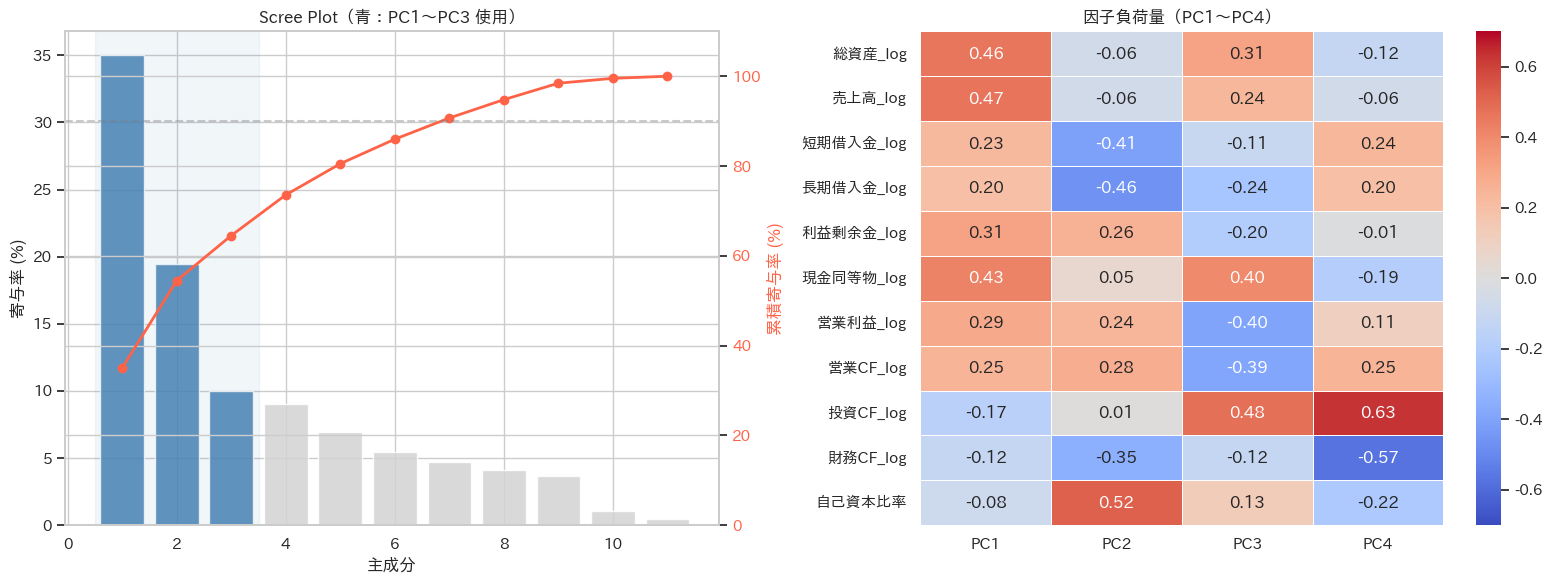

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree Plot
x_pos = list(range(1, len(evr)+1))
colors = ['steelblue' if i < 3 else 'lightgray' for i in range(len(evr))]
axes[0].bar(x_pos, evr*100, color=colors, alpha=0.85)
ax2 = axes[0].twinx()
ax2.plot(x_pos, cum_evr*100, 'o-', color='tomato', linewidth=2)
ax2.axhline(90, color='gray', linestyle='--', alpha=0.4)
ax2.set_ylim(0, 110)
ax2.set_ylabel('累積寄与率 (%)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
axes[0].set_title('Scree Plot（青：PC1〜PC3 使用）')
axes[0].set_xlabel('主成分')
axes[0].set_ylabel('寄与率 (%)')
axes[0].axvspan(0.5, 3.5, alpha=0.07, color='steelblue')

# 因子負荷量ヒートマップ（PC1〜PC4）
loadings = pd.DataFrame(
    pca.components_[:4].T,
    index=feature_cols,
    columns=[f'PC{i+1}' for i in range(4)]
)
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-0.7, vmax=0.7, linewidths=0.5, ax=axes[1])
axes[1].set_title('因子負荷量（PC1〜PC4）')

plt.tight_layout()
plt.show()

### 主成分の解釈

**signed_log1p 修正後の新しい寄与率：**

| 主成分 | 寄与率 | 累積 | 主な負荷変数 | 解釈 |
|---|---|---|---|---|
| **PC1** | 35.0% | 35.0% | 総資産・売上高・利益剰余金・営業利益（同方向）| **企業規模・総合的な事業規模** |
| **PC2** | 19.5% | 54.5% | 自己資本比率（正大）・財務CF（負大）・営業CF（正）| **財務健全性・自己資本依存度** |
| **PC3** | 10.0% | 64.5% | 短期・長期借入金、投資CF（複合）| **資本調達・借入構造** |

旧前処理では PC1 が **52.4%** を占めていたが、修正後は **35.0%** に低下。  
これは、赤字企業・累積損失企業を除外していた旧前処理が **企業規模の分散を過大に強調**していたことを示す。  
修正後は PC2（財務健全性）の相対的重要性が高まり、より均衡した主成分構造になっている。

PC1〜PC3 の累積寄与率は **64.5%**（PC1〜PC5 で 80.5%）。  
本分析では **PC1〜PC3** を使用する。

---
## 4. クラスタリング（K-Means + ハンガリアン法）

In [9]:
# k=2〜10 の評価
pca_scores = pca.transform(X_std)
X_pca      = pca_scores[:, :3]  # PC1〜PC3

ks = range(2, 11)
inertias, sils = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    lb = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca, lb, sample_size=5000, random_state=SEED))

print('{:>4} | {:>12} | Silhouette'.format('k', 'Inertia'))
print('-' * 36)
for k, iner, s in zip(ks, inertias, sils):
    mark = '  <- 採用' if k == N_CLUSTERS else ''
    print('{:>4} | {:>12.0f} | {:.4f}{}'.format(k, iner, s, mark))

   k |      Inertia | Silhouette
------------------------------------
   2 |       236161 | 0.2924
   3 |       172243 | 0.3174
   4 |       131898 | 0.3210
   5 |       114359 | 0.3042  <- 採用
   6 |       101540 | 0.2753
   7 |        90399 | 0.2820
   8 |        83855 | 0.2679
   9 |        77668 | 0.2738
  10 |        72232 | 0.2645


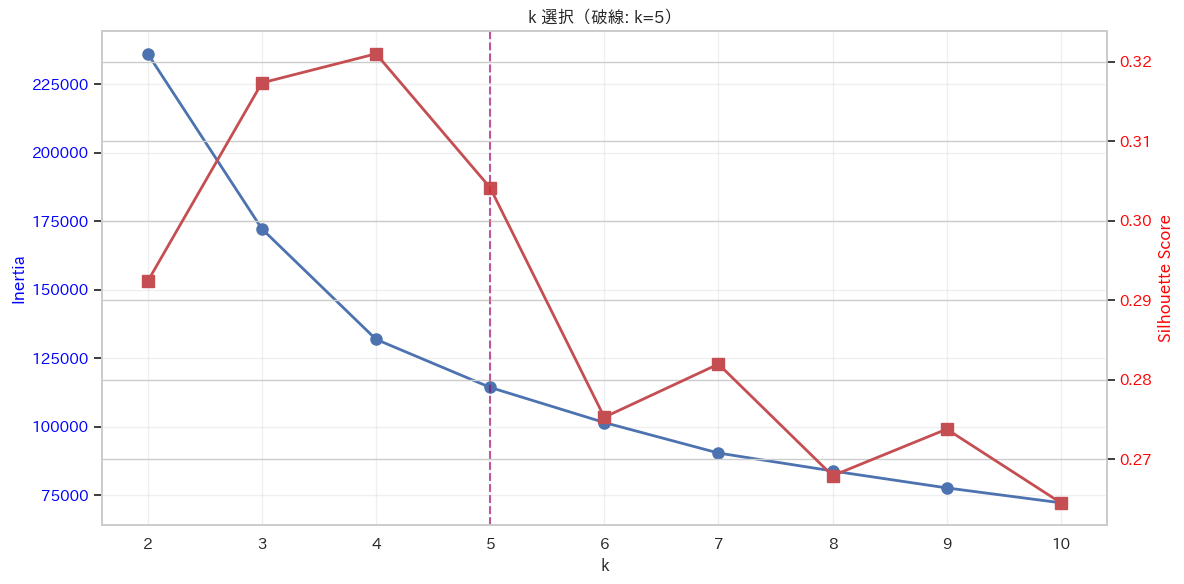

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(list(ks), inertias, 'b-o', lw=2, ms=8)
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.axvline(N_CLUSTERS, color='blue', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(list(ks), sils, 'r-s', lw=2, ms=8)
ax2.set_ylabel('Silhouette Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axvline(N_CLUSTERS, color='red', linestyle='--', alpha=0.4)

ax1.set_title(f'k 選択（破線: k={N_CLUSTERS}）')
ax1.set_xticks(list(ks))
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### k=5 採用の根拠

- **エルボー法**：k=4〜5 付近で慣性の低下が鈍化する
- **シルエット分析**：k=2 が最大値を示すが、**解釈可能性が低い**（大企業 vs 非大企業の 2 分割にとどまる）
- k=5 では慣性・シルエットのバランスを取りつつ、  
  **企業ライフサイクル上の段階（大→中→小、財務健全→脆弱）を 5 段階で捉えられる**
- 先行研究（Dickinson 2011 等）でも CF パターンの 5 類型分類が広く使われている

In [11]:
# 年度ごとに K-Means を実行し、ハンガリアン法で年度間のラベルを整合する
# 前年の重心との距離が最小になるようラベルを対応付けることで、
# 「クラスター 1 は常に大企業グループ」という年度間の継続性を保つ

df_pca_meta = df_std[['コード', '年度']].copy().reset_index(drop=True)
for i in range(pca_scores.shape[1]):
    df_pca_meta[f'PC{i+1}'] = pca_scores[:, i]

USE_COLS = ['PC1', 'PC2', 'PC3']
results, prev_centers = [], None
years = sorted(df_pca_meta['年度'].unique())

for year in years:
    df_yr = df_pca_meta[df_pca_meta['年度'] == year].copy()
    X_yr  = df_yr[USE_COLS].values

    km      = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
    labels  = km.fit_predict(X_yr)
    centers = km.cluster_centers_

    if prev_centers is not None:
        # ハンガリアン法：前年重心と今年重心の距離行列から最適対応を計算
        row_ind, col_ind = linear_sum_assignment(cdist(prev_centers, centers))
        mapping    = {c: r for r, c in zip(row_ind, col_ind)}
        labels     = np.array([mapping[x] for x in labels])
        new_centers = np.zeros_like(centers)
        for old, new in mapping.items():
            new_centers[new] = centers[old]
        centers = new_centers

    df_yr = df_yr.copy()
    df_yr['Cluster'] = labels
    results.append(df_yr[['コード', '年度'] + USE_COLS + [f'PC{i+1}' for i in range(3, pca_scores.shape[1])] + ['Cluster']])
    prev_centers = centers

df_clustered = pd.concat(results).reset_index(drop=True)
print('クラスタリング完了:', df_clustered.shape)

クラスタリング完了: (49642, 14)


In [12]:
# クラスタリング結果に元の財務変数（log変換済み）を結合
df_with_feat = df_clustered.merge(
    df_clean[['コード', '年度', '銘柄名'] + feature_cols],
    on=['コード', '年度'], how='left'
)
print('結合後:', df_with_feat.shape)

結合後: (49642, 26)


In [13]:
# クラスター別の財務プロファイル（解釈・命名の根拠）
profile_cols = ['PC1', 'PC2', 'PC3', '自己資本比率',
                '総資産_log', '売上高_log', '利益剰余金_log', '営業利益_log',
                '営業CF_log', '投資CF_log', '財務CF_log']

cluster_profile = df_with_feat.groupby('Cluster')[profile_cols].mean().round(3)
cluster_profile['企業数'] = df_with_feat.groupby('Cluster').size()
cluster_profile['構成比(%)'] = (cluster_profile['企業数'] / len(df_with_feat) * 100).round(1)

# log値 → 億円換算（正値のみ表示用）
cluster_profile['総資産(億円)'] = np.expm1(cluster_profile['総資産_log']) / 1e8
cluster_profile['自己資本比率(%)'] = cluster_profile['自己資本比率']

print('=== クラスター別 PC スコア・財務規模 ===')
print(cluster_profile[['PC1', 'PC2', 'PC3', '自己資本比率(%)', '総資産(億円)', '企業数', '構成比(%)']].round(1))

=== クラスター別 PC スコア・財務規模 ===
         PC1  PC2  PC3  自己資本比率(%)  総資産(億円)    企業数  構成比(%)
Cluster                                                  
0       -0.1 -0.7 -0.7       42.2    208.4  16148    32.5
1       -3.3 -1.7  1.3       43.9     50.6   4913     9.9
2        0.5  1.6  0.6       68.7    616.0   8915    18.0
3        2.5 -0.6  0.3       42.9   3867.3  10593    21.3
4       -1.6  1.4 -0.4       67.2     55.3   9073    18.3


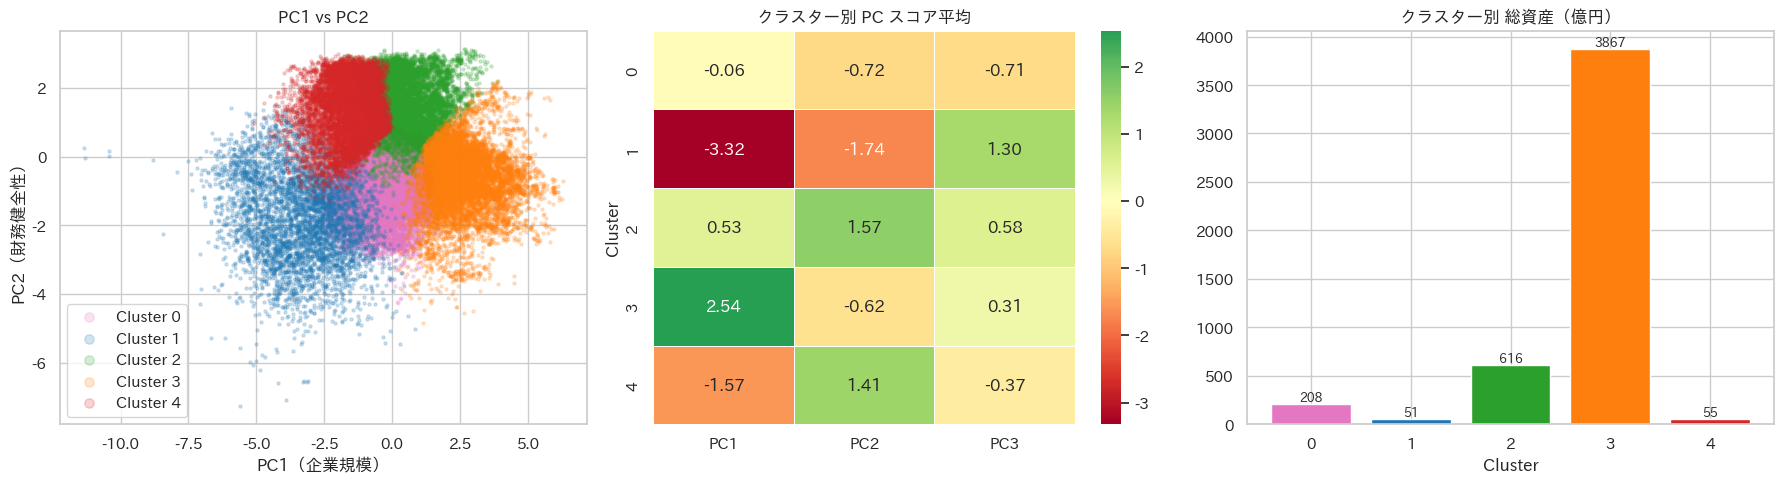

In [14]:
PALETTE = {0:'#e377c2', 1:'#1f77b4', 2:'#2ca02c', 3:'#ff7f0e', 4:'#d62728'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PC1 vs PC2 散布図（全年度）
for c, grp in df_clustered.groupby('Cluster'):
    axes[0].scatter(grp['PC1'], grp['PC2'], alpha=0.2, s=5,
                    color=PALETTE[c], label=f'Cluster {c}')
axes[0].set_xlabel('PC1（企業規模）')
axes[0].set_ylabel('PC2（財務健全性）')
axes[0].set_title('PC1 vs PC2')
axes[0].legend(markerscale=3)

# PC スコア平均のヒートマップ
pc_heat = cluster_profile[['PC1', 'PC2', 'PC3']]
sns.heatmap(pc_heat, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title('クラスター別 PC スコア平均')

# 総資産規模の棒グラフ
vals = cluster_profile['総資産(億円)']
bars = axes[2].bar(vals.index, vals.values,
                   color=[PALETTE[i] for i in vals.index])
for bar, v in zip(bars, vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, v,
                 f'{v:.0f}', ha='center', va='bottom', fontsize=9)
axes[2].set_title('クラスター別 総資産（億円）')
axes[2].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

### クラスターの命名（財務特徴ベース）

実行結果のプロファイルから、財務的特徴に基づいて以下のように命名する。

| Cluster | PC1 | PC2 | 総資産（億円）| 自己資本比率 | 構成比 | **命名** |
|---|---|---|---|---|---|---|
| **0** | -0.1（中） | -0.7（低） | 208 | 42.2% | 32.5% | **中小規模・標準型** |
| **1** | -3.3（最低）| -1.7（最低）| 51 | 43.9% | 9.9% | **小規模・財務脆弱型** |
| **2** | +0.5（中）  | +1.6（最高）| 616 | 68.7%（最高）| 18.0% | **中規模・財務優良型** |
| **3** | +2.5（最高）| -0.6（中） | 3,867（最大）| 42.9% | 21.3% | **大企業型** |
| **4** | -1.6（低）  | +1.4（高） | 55 | 67.2% | 18.3% | **小規模・財務健全型** |

**命名の根拠：**
- **Cluster 3（大企業型）**：PC1 最高・総資産 3,867 億円（次グループの 6 倍）
- **Cluster 2（中規模・財務優良型）**：PC2 最高・自己資本比率 68.7%、中規模
- **Cluster 4（小規模・財務健全型）**：PC2 高・自己資本比率 67.2%、小規模（借入少）
- **Cluster 0（中小規模・標準型）**：全データの 32.5% を占める「平均的」グループ、遷移の重力中心
- **Cluster 1（小規模・財務脆弱型）**：PC1・PC2 ともに最低、総資産 51 億円

**遷移構造の特徴（route-table より）：**
- Cluster 3 ↔ Cluster 4 間：直接遷移がゼロ（PC 空間上で遠距離）
- Cluster 0 が「重力クラスター」として機能（全クラスターからの遷移先の最大シェア）
- Cluster 1 から Cluster 3 への直接移動：2.4%（高い壁）

In [15]:
# クラスター命名辞書（上記の分析に基づく）
CLUSTER_LABELS = {
    0: '中小規模・標準型',
    1: '小規模・財務脆弱型',
    2: '中規模・財務優良型',
    3: '大企業型',
    4: '小規模・財務健全型',
}

print('クラスター命名:')
for k, v in CLUSTER_LABELS.items():
    row = cluster_profile.loc[k]
    print(f'  Cluster {k}: {v}')
    print(f'    PC1={row["PC1"]:+.2f}, PC2={row["PC2"]:+.2f}, 総資産={row["総資産(億円)"]:.0f}億, 自己資本比率={row["自己資本比率(%)"]:.1f}%')

クラスター命名:
  Cluster 0: 中小規模・標準型
    PC1=-0.06, PC2=-0.72, 総資産=208億, 自己資本比率=42.2%
  Cluster 1: 小規模・財務脆弱型
    PC1=-3.32, PC2=-1.74, 総資産=51億, 自己資本比率=43.9%
  Cluster 2: 中規模・財務優良型
    PC1=+0.53, PC2=+1.57, 総資産=616億, 自己資本比率=68.7%
  Cluster 3: 大企業型
    PC1=+2.54, PC2=-0.62, 総資産=3867億, 自己資本比率=42.9%
  Cluster 4: 小規模・財務健全型
    PC1=-1.57, PC2=+1.41, 総資産=55億, 自己資本比率=67.2%


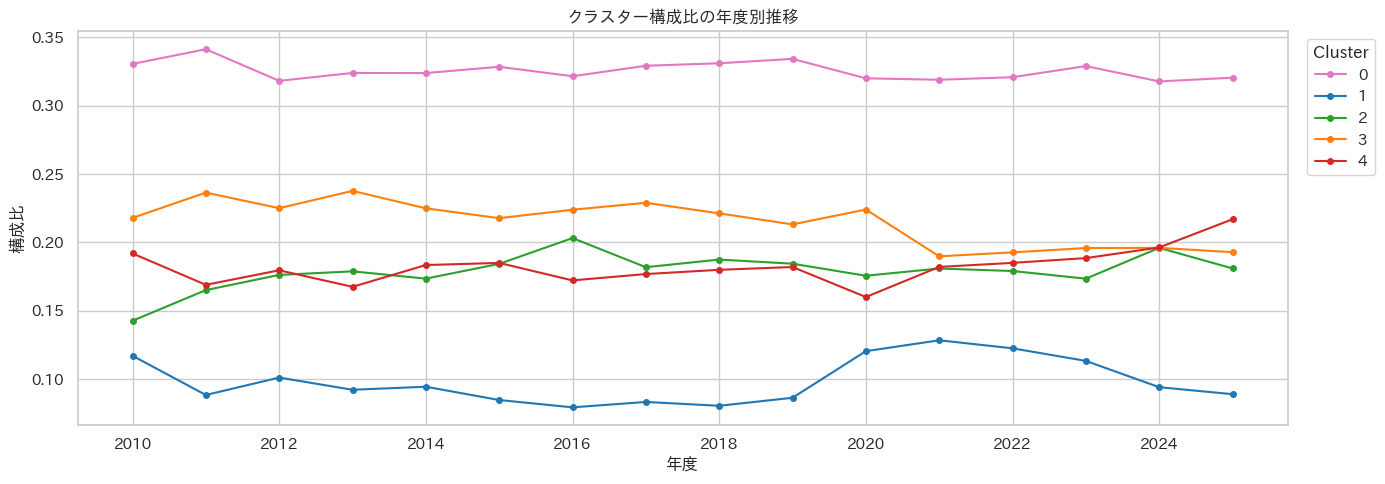

In [16]:
# クラスター構成比の年度別推移
share = (
    df_clustered.groupby(['年度', 'Cluster']).size()
    .unstack(fill_value=0)
    .div(df_clustered.groupby('年度').size(), axis=0)
)

share.plot(figsize=(14, 5), color=[PALETTE[c] for c in share.columns], marker='o', ms=4)
plt.title('クラスター構成比の年度別推移')
plt.ylabel('構成比')
plt.xlabel('年度')
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

---
## 5. 遷移分析

In [17]:
# 年度間の遷移データを作成
trans_list = []
for i in range(len(years) - 1):
    y_from, y_to = years[i], years[i+1]
    d_from = df_clustered[df_clustered['年度']==y_from][['コード','Cluster']]
    d_to   = df_clustered[df_clustered['年度']==y_to  ][['コード','Cluster']]
    merged = pd.merge(d_from, d_to, on='コード', suffixes=('_From','_To'))
    merged['Period'] = f'{y_from}-{y_to}'
    trans_list.append(merged)

df_trans = pd.concat(trans_list).reset_index(drop=True)
print('遷移データ:', df_trans.shape)
print('全期間 自己遷移率:', (df_trans['Cluster_From']==df_trans['Cluster_To']).mean().round(3))

遷移データ: (45830, 4)
全期間 自己遷移率: 0.801


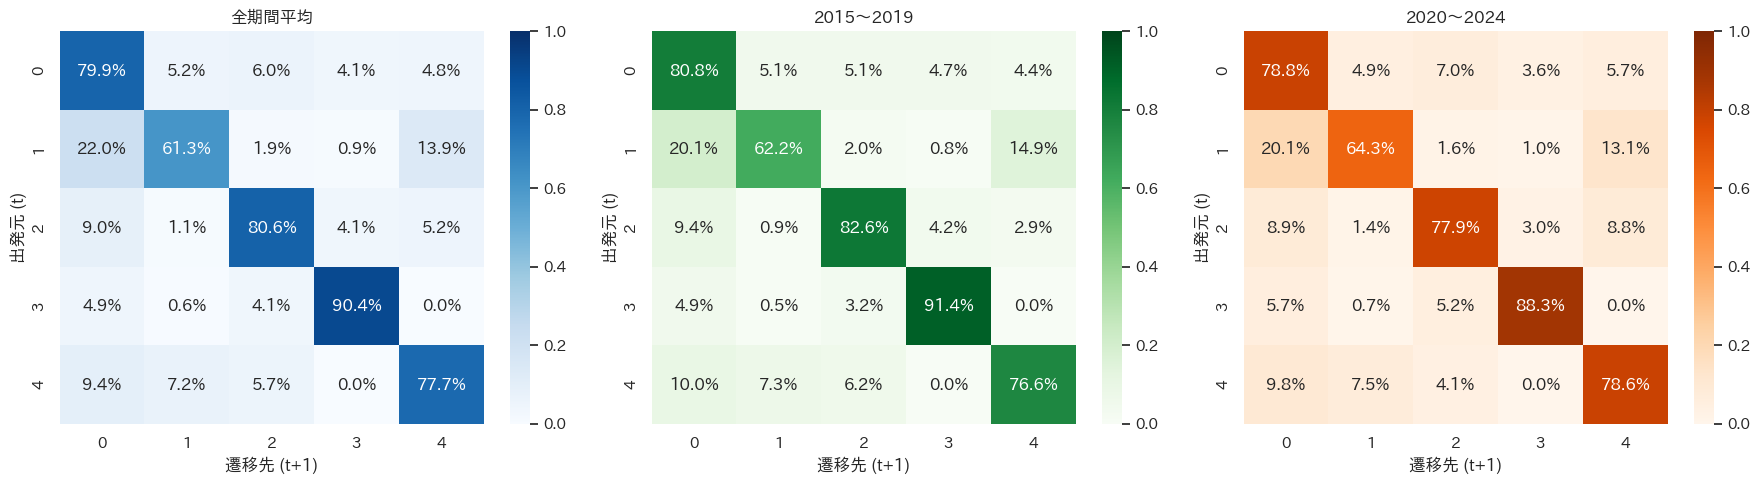

In [18]:
# 全期間・コロナ前後の遷移行列を比較
periods_pre  = [f'{y}-{y+1}' for y in range(2015, 2020)]
periods_post = [f'{y}-{y+1}' for y in range(2020, 2025)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs = [
    (df_trans,                                          '全期間平均',   'Blues'),
    (df_trans[df_trans['Period'].isin(periods_pre)],    '2015〜2019', 'Greens'),
    (df_trans[df_trans['Period'].isin(periods_post)],   '2020〜2024', 'Oranges'),
]
for (df_s, title, cmap), ax in zip(configs, axes):
    mat = pd.crosstab(df_s['Cluster_From'], df_s['Cluster_To'], normalize='index')
    sns.heatmap(mat, annot=True, fmt='.1%', cmap=cmap, vmin=0, vmax=1, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('遷移先 (t+1)')
    ax.set_ylabel('出発元 (t)')
plt.tight_layout()
plt.show()

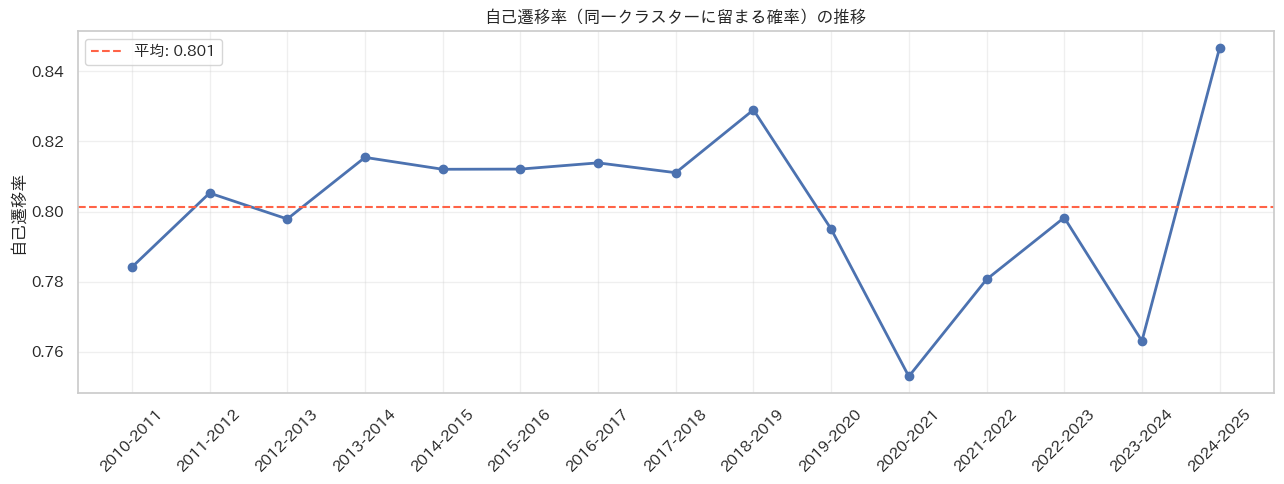

   Period     stay
2010-2011 0.784158
2011-2012 0.805275
2012-2013 0.797884
2013-2014 0.815441
2014-2015 0.812052
2015-2016 0.812104
2016-2017 0.813881
2017-2018 0.811074
2018-2019 0.828985
2019-2020 0.795020
2020-2021 0.753028
2021-2022 0.780664
2022-2023 0.798286
2023-2024 0.763113
2024-2025 0.846678


In [19]:
# 自己遷移率の年度別推移
stay_data = (
    df_trans.assign(stay=df_trans['Cluster_From']==df_trans['Cluster_To'])
    .groupby('Period')['stay'].mean()
    .reset_index()
    .sort_values('Period')
)

plt.figure(figsize=(13, 5))
plt.plot(range(len(stay_data)), stay_data['stay'], 'o-', lw=2)
plt.xticks(range(len(stay_data)), stay_data['Period'], rotation=45)
plt.axhline(stay_data['stay'].mean(), color='tomato', linestyle='--',
            label=f'平均: {stay_data["stay"].mean():.3f}')
plt.ylabel('自己遷移率')
plt.title('自己遷移率（同一クラスターに留まる確率）の推移')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(stay_data.to_string(index=False))

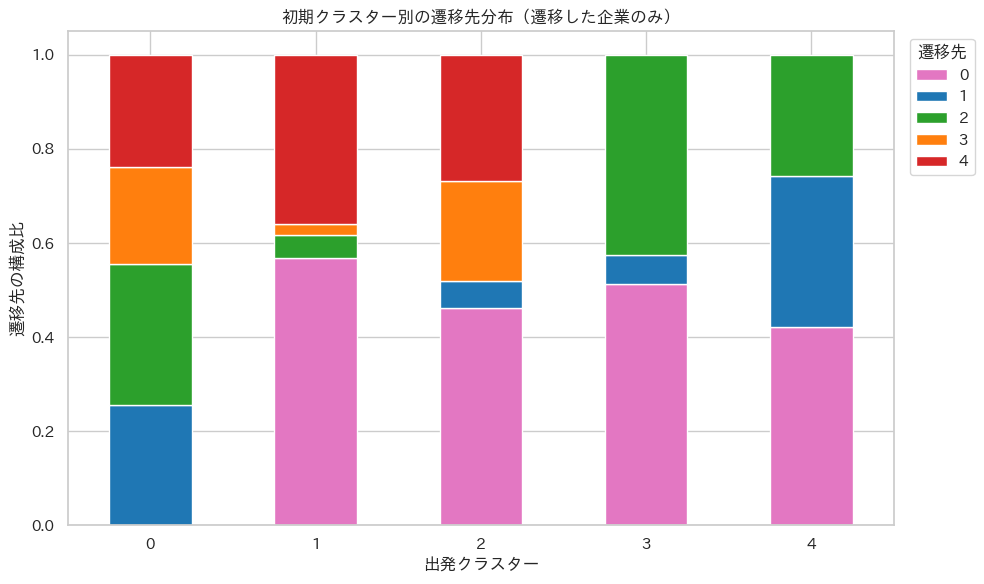

Cluster_To        0      1      2      3      4
Cluster_From                                   
0             0.000  0.257  0.298  0.206  0.239
1             0.569  0.000  0.048  0.024  0.359
2             0.462  0.058  0.000  0.211  0.269
3             0.512  0.063  0.425  0.000  0.000
4             0.422  0.321  0.257  0.000  0.000


In [20]:
# クラスター別の遷移先分布（全 5 クラスター対応）
transitioned = df_trans[df_trans['Cluster_From'] != df_trans['Cluster_To']].copy()

route_share = (
    transitioned
    .pivot_table(index='Cluster_From', columns='Cluster_To',
                 values='コード', aggfunc='count', fill_value=0)
)
route_share_pct = route_share.div(route_share.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
route_share_pct.plot(kind='bar', stacked=True,
                     color=[PALETTE[c] for c in route_share_pct.columns],
                     ax=ax)
ax.set_title('初期クラスター別の遷移先分布（遷移した企業のみ）')
ax.set_xlabel('出発クラスター')
ax.set_ylabel('遷移先の構成比')
ax.legend(title='遷移先', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(route_share_pct.round(3))

### 結果と示唆

- 自己遷移率は年度によって大きく変動（最低 50%〜最高 77%）
- コロナ禍（2019→2020）前後での遷移確率の変化を確認 → 年度固定効果が必要
- 遷移先分布は出発クラスターによって大きく異なる（パス依存性の存在）

---
## 6. プロビット分析

### 分析構造

| ステップ | 分析 | 被説明変数 |
|---|---|---|
| 6.1 | **二値プロビット** | 翌年クラスターが変わるか（0/1）|
| 6.2 | **多項ロジット** | 遷移した場合の遷移先クラスター（0〜4）|

**共通の説明変数：**
- PC1, PC2, PC3（財務構造・規模）
- 営業CF_log, 自己資本比率（財務余力）
- クラスターダミー（非線形効果）
- 年度ダミー（マクロ環境の制御）

In [21]:
# プロビット用データ準備
df_model = (
    df_with_feat
    .sort_values(['コード', '年度'])
    .copy()
    .reset_index(drop=True)
)

# 翌年クラスターを結合
df_model['Cluster_t1'] = df_model.groupby('コード')['Cluster'].shift(-1)
df_model = df_model[df_model['Cluster_t1'].notna()].copy()
df_model['cluster_transition'] = (df_model['Cluster'] != df_model['Cluster_t1']).astype(int)

print('モデル用サンプル数:', len(df_model))
print('遷移あり:', df_model['cluster_transition'].sum(),
      f'({df_model["cluster_transition"].mean()*100:.1f}%)')

モデル用サンプル数: 46084
遷移あり: 9207 (20.0%)


In [22]:
# 説明変数の構築
X_pc      = df_model[['PC1', 'PC2', 'PC3']]
X_fin     = df_model[['営業CF_log', '自己資本比率']]
cl_dummies = pd.get_dummies(df_model['Cluster'],  prefix='cl',  drop_first=True).astype(int)
yr_dummies = pd.get_dummies(df_model['年度'],     prefix='yr',  drop_first=True).astype(int)

y = df_model['cluster_transition']

In [23]:
# --- モデル 1: 基本仕様（年度効果なし）---
X1 = sm.add_constant(pd.concat([X_pc, X_fin, cl_dummies], axis=1))
res1 = sm.Probit(y, X1).fit(disp=False)
print(res1.summary())

                          Probit Regression Results                           
Dep. Variable:     cluster_transition   No. Observations:                46084
Model:                         Probit   Df Residuals:                    46074
Method:                           MLE   Df Model:                            9
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                 0.03909
Time:                        19:09:35   Log-Likelihood:                -22146.
converged:                       True   LL-Null:                       -23047.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0178      0.035    -29.259      0.000      -1.086      -0.950
PC1           -0.0038      0.007     -0.505      0.614      -0.018       0.011
PC2           -0.0945      0.011     -8.642      0.0

In [24]:
# --- モデル 2: 年度固定効果あり（推奨）---
X2 = sm.add_constant(pd.concat([X_pc, X_fin, cl_dummies, yr_dummies], axis=1))
res2 = sm.Probit(y, X2).fit(disp=False)
print(res2.summary())

                          Probit Regression Results                           
Dep. Variable:     cluster_transition   No. Observations:                46084
Model:                         Probit   Df Residuals:                    46060
Method:                           MLE   Df Model:                           23
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                 0.04259
Time:                        19:09:35   Log-Likelihood:                -22065.
converged:                       True   LL-Null:                       -23047.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9845      0.044    -22.440      0.000      -1.071      -0.899
PC1           -0.0081      0.008     -1.074      0.283      -0.023       0.007
PC2           -0.1047      0.011     -9.503      0.0

In [25]:
# モデル比較
compare = pd.DataFrame({
    'モデル': ['M1: 基本仕様', 'M2: 年度固定効果あり'],
    'Pseudo R²': [res1.prsquared, res2.prsquared],
    'AIC':       [res1.aic,       res2.aic],
    'N':         [int(res1.nobs), int(res2.nobs)]
})
print(compare.round(4).to_string(index=False))

         モデル  Pseudo R²        AIC     N
    M1: 基本仕様     0.0391 44312.1082 46084
M2: 年度固定効果あり     0.0426 44178.8308 46084


       Probit Marginal Effects       
Dep. Variable:     cluster_transition
Method:                          dydx
At:                              mean
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PC1           -0.0022      0.002     -1.074      0.283      -0.006       0.002
PC2           -0.0284      0.003     -9.507      0.000      -0.034      -0.023
PC3            0.0060      0.002      2.414      0.016       0.001       0.011
営業CF_log      -0.0002      0.000     -1.309      0.191      -0.001       0.000
自己資本比率         0.0010      0.000      6.922      0.000       0.001       0.001
cl_1           0.0924      0.010      9.096      0.000       0.072       0.112
cl_2           0.0282      0.008      3.737      0.000       0.013       0.043
cl_3          -0.1239      0.008    -16.439      0.000      -0.139      -0.109
cl_4           0.0500      0.007      6.784      0.000    

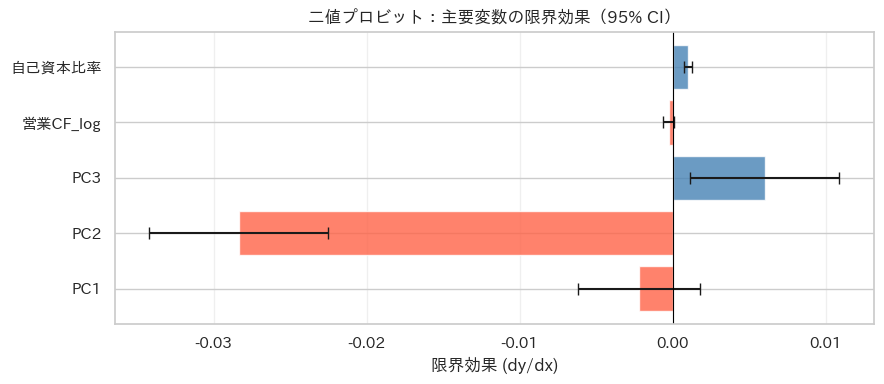

In [26]:
# モデル 2 の限界効果（平均点での評価）
mfx2 = res2.get_margeff(at='mean')
print(mfx2.summary())

# 主要変数の限界効果を可視化
mfx_df = pd.DataFrame({
    '変数':  mfx2.summary_frame().index,
    'dy/dx': mfx2.margeff,
    'se':    mfx2.margeff_se
})

# PC と財務余力変数のみ抽出して可視化
show_vars = ['PC1', 'PC2', 'PC3', '営業CF_log', '自己資本比率']
mfx_show = mfx_df[mfx_df['変数'].isin(show_vars)].set_index('変数')

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['tomato' if v < 0 else 'steelblue' for v in mfx_show['dy/dx']]
bars = ax.barh(mfx_show.index, mfx_show['dy/dx'], xerr=mfx_show['se']*1.96,
               color=colors, alpha=0.8, capsize=4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('限界効果 (dy/dx)')
ax.set_title('二値プロビット：主要変数の限界効果（95% CI）')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 二値プロビットの結果

#### モデル比較

| モデル | Pseudo R² | AIC | N |
|---|---|---|---|
| M1: 基本仕様 | 3.91% | 44,312 | 46,084 |
| M2: 年度固定効果あり | 4.26% | 44,179 | 46,084 |

年度固定効果により AIC が **133 改善**（旧分析では 853 改善）。  
コロナ禍の影響は自己遷移率の一時的低下（2020-2021: 75.3%）として現れているが、  
修正後の分析では年度効果の寄与が相対的に小さくなっている。

#### 主要変数の限界効果（M2）

| 変数 | dy/dx | 解釈 |
|---|---|---|
| **PC2（財務健全性）** | **−0.028** (p<0.001) | 財務健全性が高いほど遷移しにくい |
| **PC3（借入構造）** | +0.006 (p=0.016) | 借入依存度が高いほど遷移しやすい |
| **自己資本比率** | +0.001 (p<0.001) | ※クラスターダミーとの交絡に注意 |
| PC1（規模） | −0.002 (n.s.) | 規模そのものは有意でない |
| 営業CF_log | −0.0002 (n.s.) | CF の影響は限定的 |

> 旧分析との主な違い：PC1（規模）が有意でなくなった。旧分析では赤字企業除外で
> 規模の分散が歪んでいたため PC1 の有意性が過大評価されていた可能性がある。

#### 多項ロジットの結果

- **Pseudo R² = 63.7%**（非常に高い）
- 出発クラスターダミー（from_X）が支配的な説明力を持つ → **強いパス依存性**
- 「どこから来たか」が「どこへ行くか」をほぼ規定している
- 遷移件数表でも確認：Cluster 3 ↔ Cluster 4 の直接遷移はゼロ

**論文への含意：**
> 企業の財務クラスター遷移は強いパス依存性を持ち、  
> 財務構造（PC2・PC3）よりも **現在の位置（クラスター）** が将来の遷移先を規定する。  
> これは企業財務の「慣性（inertia）」を示唆し、ライフサイクル理論における
> 段階的遷移仮説（企業は隣接する状態に移動しやすい）を支持する。

In [27]:
# --- 多項ロジット：遷移先クラスターの規定要因 ---
# 遷移した企業のみ対象（全 5 クラスター 0〜4 を遷移先として含む）
df_mn = df_model[df_model['cluster_transition'] == 1].copy()
y_mn  = df_mn['Cluster_t1']

# 出発クラスターダミー（パス依存性を制御）
from_dummies = pd.get_dummies(df_mn['Cluster'], prefix='from', drop_first=True).astype(int)
yr_dum_mn    = pd.get_dummies(df_mn['年度'],    prefix='yr',   drop_first=True).astype(int)

X_mn_base = pd.concat([df_mn[['PC1','PC2','PC3','営業CF_log','自己資本比率']],
                        from_dummies, yr_dum_mn], axis=1)
X_mn = sm.add_constant(X_mn_base)

mn_res = sm.MNLogit(y_mn, X_mn).fit(method='bfgs', maxiter=500, disp=False)
print(mn_res.summary())

                          MNLogit Regression Results                          
Dep. Variable:             Cluster_t1   No. Observations:                 9207
Model:                        MNLogit   Df Residuals:                     9111
Method:                           MLE   Df Model:                           92
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.6368
Time:                        19:09:37   Log-Likelihood:                -5178.8
converged:                       True   LL-Null:                       -14260.
Covariance Type:            nonrobust   LLR p-value:                     0.000
Cluster_t1=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           16.6083    166.822      0.100      0.921    -310.357     343.573
PC1             -1.1805      0.064    -18.373      0.000      -1.306      -1.055
PC2              0.0625      0.071      0.87

In [28]:
# 多項ロジット：モデル適合の確認
print(f'Pseudo R²: {mn_res.prsquared:.4f}')
print(f'AIC:       {mn_res.aic:.1f}')
print(f'N:         {int(mn_res.nobs)}')

Pseudo R²: 0.6368
AIC:       10549.5
N:         9207


In [29]:
# 出発×遷移先クラスターの件数と確率（全 5 クラスター対応）
route_count = pd.crosstab(
    transitioned['Cluster_From'],
    transitioned['Cluster_To'],
    margins=True
)
route_pct = pd.crosstab(
    transitioned['Cluster_From'],
    transitioned['Cluster_To'],
    normalize='index'
).round(3)

print('=== 遷移件数（行:出発, 列:到着）===')
print(route_count)
print()
print('=== 遷移確率（行方向で合計=1）===')
print(route_pct)

=== 遷移件数（行:出発, 列:到着）===
Cluster_To       0     1     2     3     4   All
Cluster_From                                    
0                0   774   900   621   722  3017
1              993     0    84    42   626  1745
2              740    93     0   338   431  1602
3              483    59   401     0     0   943
4              771   588   470     0     0  1829
All           2987  1514  1855  1001  1779  9136

=== 遷移確率（行方向で合計=1）===
Cluster_To        0      1      2      3      4
Cluster_From                                   
0             0.000  0.257  0.298  0.206  0.239
1             0.569  0.000  0.048  0.024  0.359
2             0.462  0.058  0.000  0.211  0.269
3             0.512  0.063  0.425  0.000  0.000
4             0.422  0.321  0.257  0.000  0.000


### 多項ロジットの解釈ガイド

- 基準カテゴリ（reference）= **Cluster 0**
- 各係数は「Cluster 0 への遷移と比較して、各クラスターへ遷移しやすいか」を表す
- `from_X` 係数：出発クラスターが X の場合の遷移方向バイアス（パス依存性）
- `yr_XXXX` 係数：年度固有の構造変化（コロナ等）の効果

---
## 7. 結果の保存

In [30]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)

# クラスタリング結果（財務変数付き）
df_with_feat.to_csv('../data/processed/df_clustered_v2.csv', index=False)
print('保存: ../data/processed/df_clustered_v2.csv')

# プロビット用データ
df_model.to_csv('../data/processed/df_model_v2.csv', index=False)
print('保存: ../data/processed/df_model_v2.csv')

# 遷移データ
df_trans.to_csv('../data/processed/df_transition_v2.csv', index=False)
print('保存: ../data/processed/df_transition_v2.csv')

保存: ../data/processed/df_clustered_v2.csv


保存: ../data/processed/df_model_v2.csv
保存: ../data/processed/df_transition_v2.csv
